In [1]:
import torch
import numpy as np
import gymnasium as gym

import torch
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from PIL import Image
from pyvirtualdisplay import Display
import gymnasium_robotics
import metaworld
gym.register_envs(gymnasium_robotics)

# os.environ["DISPLAY"] = "99"
rand_seed=123
device = torch.device(f"cuda:{2}" if torch.cuda.is_available() else "cpu")

In [2]:
import os
os.environ['MUJOCO_GL'] = 'egl'
# disp = Display(visible=0, size=(480, 480))
# disp.start()

  0%|          | 0/4 [00:00<?, ?it/s]

(400, 600, 3)
(400, 600, 3)
(400, 600, 3)


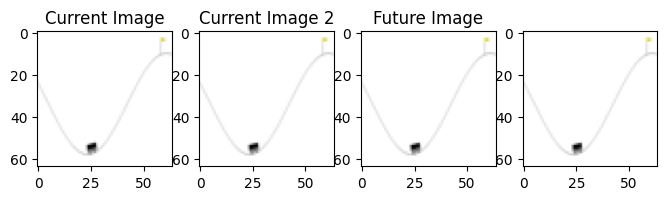

 75%|███████▌  | 3/4 [00:00<00:00, 20.28it/s]

(400, 600, 3)


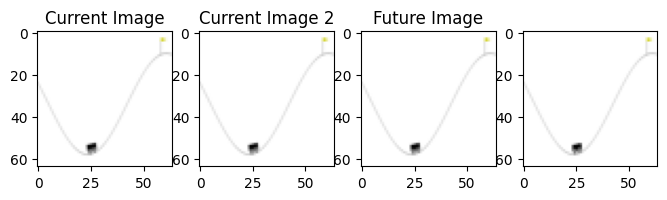

100%|██████████| 4/4 [00:00<00:00, 13.79it/s]

Failures (resets): 0


In [ ]:
env_name = "AntMaze_UMaze-v5" # agent centric view
env_name = "PointMaze_UMaze-v3"
env_name = "MountainCarContinuous-v0"
env = gym.make(env_name, render_mode="rgb_array") #, continuing_task=True)

num_prev = 3
data_length = num_prev + 1
obs, _ = env.reset(seed=rand_seed)

dataset = []  # List of (obs, action, image)
next_imgs = []
obs_arr = []
acts_arr = []

fail_counter = 0
for obs_counter in tqdm(range(data_length)):
    # if obs_counter + 3 >= data_length:
    #     break
    if len(next_imgs) == 0:
        rendered_img = env.render()
        # rendered_img = rendered_img[:, 50:-50, :] # Acrobot
        # rendered_img = rendered_img[100:-50, 100:-100, :]
        # rendered_img = rendered_img[110:-70, 20:-20, :]
        img_resize = Image.fromarray(rendered_img).resize((64, 64)) #.resize((cropped.shape[1] // 8 * 8, cropped.shape[0] // 8 * 8))
        next_imgs.append(np.asarray(img_resize))
        obs_arr.append(obs.copy())

    act = env.action_space.sample()
    next_obs, rew, done, _, _ = env.step(act)
    acts_arr.append(act)
    
    if done:
        fail_counter += 1
        obs, _ = env.reset()
        next_imgs = []
        obs_arr = []
        acts_arr = []
    else:
        if len(next_imgs) == num_prev + 1:
            obs_arr.pop(0)
            next_imgs.pop(0)
            acts_arr.pop(0)
        next_img = env.render()
        # next_img = next_img[:, 50:-50, :] # [y dir, x dir, color]
        # next_img = next_img[100:-50, 100:-100, :] # [y dir, x dir, color]
        # next_img = next_img[100:-50, :-100, :]
        # next_img = next_img[110:-70, 20:-20, :]
        next_img = Image.fromarray(next_img).resize((64, 64)) #.resize((cropped.shape[1] // 8 * 8, cropped.shape[0] // 8 * 8)).resize((cropped.shape[1] // 8 * 8, cropped.shape[0] // 8 * 8))
        # next_img = Image.fromarray(next_img).resize((96, 96)) #.resize((cropped.shape[1] // 8 * 8, cropped.shape[0] // 8 * 8)).resize((cropped.shape[1] // 8 * 8, cropped.shape[0] // 8 * 8))
        next_imgs.append(np.asarray(next_img))
        obs_arr.append(next_obs.copy())
        
        if len(next_imgs) == num_prev + 1:
            
            fig, ax = plt.subplots(1, num_prev+1, figsize=(8, 10))
            ax[0].set_title("Current Image")
            ax[1].set_title("Current Image 2")
            ax[2].set_title("Future Image")
            for i, img in enumerate(next_imgs):
                ax[i].imshow(img)
                # ax[i].set_xlabel(np.array2string(obs_arr[i], formatter={'float_kind': lambda x: "%.2f" % x}))
            plt.show()
            plt.close(fig)
            # Store only valid transitions
            dataset.append({
                'obs': np.asarray(obs_arr).copy(),
                'action': np.asarray(acts_arr).copy(),
                'image': np.asarray(next_imgs[:-1]).copy(),
                'next_image': next_imgs[-1].copy()
            })
        obs = next_obs
print(f"Failures (resets): {fail_counter}")